In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from statsmodels.tsa.statespace.varmax import VARMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
import itertools, warnings
warnings.filterwarnings("ignore")

FIGURES_DIR = Path("figures"); FIGURES_DIR.mkdir(exist_ok=True)
RESULTS_DIR = Path("results"); RESULTS_DIR.mkdir(exist_ok=True)
DATA_DIR    = "data/"

TARGET_COL = "price"   # ← update to your primary display_name column

# If True: grid search on TARGET_COL only (fast), then refit winner with all endog
# If False: grid search on all endog columns (slow)
FAST_GRID_SEARCH = True

In [2]:
df_fruitveg          = pd.read_csv(f"{DATA_DIR}cleaned_fruit_veg.csv")
df_fruitveg["date"]  = pd.to_datetime(df_fruitveg["date"])
df_fruitveg["price"] = pd.to_numeric(df_fruitveg["price"], errors="coerce")

price_wide = (
    df_fruitveg
    .groupby(["date","display_name"])["price"]
    .mean()
    .unstack("display_name")
    .sort_index()
    .ffill().bfill()
)

weekly_idx = price_wide.index

fuel1    = pd.read_csv(f"{DATA_DIR}weekly_road_fuel_prices_2003_to_2017.csv")
fuel2    = pd.read_csv(f"{DATA_DIR}weekly_road_fuel_prices_2018_to_now.csv")
df_fuel  = pd.concat([fuel1, fuel2], ignore_index=True)
date_col = [c for c in df_fuel.columns if c.strip().lower() == "date"][0]
ulsp_col = [c for c in df_fuel.columns if "ulsp" in c.lower()][0]
df_fuel["date"]       = pd.to_datetime(df_fuel[date_col], dayfirst=True)
df_fuel["fuel_price"] = pd.to_numeric(df_fuel[ulsp_col], errors="coerce")
fuel_weekly = df_fuel[["date","fuel_price"]].dropna().set_index("date")["fuel_price"].sort_index()

raw_cpi      = pd.read_excel(
    f"{DATA_DIR}consumerpriceinflationdetailedreferencetables.xlsx",
    sheet_name="Table 15a, 15b, 15c", skiprows=5, header=0)
raw_cpi.columns = raw_cpi.columns.str.strip()
months   = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
cpi_rows = raw_cpi[raw_cpi["Unnamed: 1"].astype(str).str.match(r"^\d{4}$", na=False)].copy()
cpi_rows = cpi_rows[["Unnamed: 1"] + months].copy()
cpi_rows.columns = ["year"] + months
cpi_rows["year"] = cpi_rows["year"].astype(int)
cpi_long = cpi_rows.melt(id_vars="year", value_vars=months, var_name="month", value_name="cpi")
cpi_long["cpi"]  = pd.to_numeric(cpi_long["cpi"].astype(str).str.strip(), errors="coerce")
cpi_long["date"] = pd.to_datetime(cpi_long["year"].astype(str) + " " + cpi_long["month"] + " 01", format="%Y %b %d")
cpi_monthly      = cpi_long.dropna(subset=["cpi"]).set_index("date")["cpi"].sort_index()

raw_api         = pd.read_csv(f"{DATA_DIR}API_20260129.csv")
raw_api["date"] = pd.to_datetime(raw_api["date"])
raw_api["api"]  = pd.to_numeric(raw_api["index"], errors="coerce")
api_monthly     = raw_api[["date","api"]].dropna().set_index("date")["api"].sort_index()

raw_fert = pd.read_excel(
    f"{DATA_DIR}GBFertiliserPriceSeries.xlsx",
    sheet_name="GB Fertiliser Price Series ", skiprows=13, dtype=str)
an_col             = "AN – UK produced (34.5% N)"
raw_fert["date"]       = pd.to_datetime(raw_fert["Month"], errors="coerce")
raw_fert["fertiliser"] = pd.to_numeric(raw_fert[an_col], errors="coerce")
fert_monthly       = raw_fert[["date","fertiliser"]].dropna().set_index("date")["fertiliser"].sort_index()

raw_sppi         = pd.read_csv(f"{DATA_DIR}series-210226.csv", names=["period","value"])
raw_sppi         = raw_sppi[raw_sppi["period"].str.match(r"^\d{4} Q[1-4]$", na=False)].copy()
raw_sppi["sppi"] = pd.to_numeric(raw_sppi["value"], errors="coerce")
def quarter_to_date(s):
    year, q = s.split(" Q")
    return pd.Timestamp(year=int(year), month=(int(q)-1)*3+1, day=1)
raw_sppi["date"] = raw_sppi["period"].apply(quarter_to_date)
sppi_quarterly   = raw_sppi[["date","sppi"]].dropna().set_index("date")["sppi"].sort_index()

def locf_to_weekly(series, weekly_index):
    series   = series.groupby(series.index).mean()
    combined = series.reindex(series.index.union(weekly_index)).ffill()
    return combined.reindex(weekly_index)

exog_df = pd.DataFrame({
    "fuel_price": locf_to_weekly(fuel_weekly,    weekly_idx).values,
    "cpi":        locf_to_weekly(cpi_monthly,    weekly_idx).values,
    "api":        locf_to_weekly(api_monthly,    weekly_idx).values,
    "fertiliser": locf_to_weekly(fert_monthly,   weekly_idx).values,
    "sppi":       locf_to_weekly(sppi_quarterly, weekly_idx).values,
}, index=weekly_idx)

df = pd.concat([price_wide, exog_df], axis=1).dropna()
ENDOG_COLS = price_wide.columns.tolist()
EXOG_COLS  = ["fuel_price","cpi","api","fertiliser","sppi"]

print(f"Dataset:      {df.shape} | {df.index[0].date()} → {df.index[-1].date()}")
print(f"Endog cols:   {ENDOG_COLS}")
print(f"Exog cols:    {EXOG_COLS}")

Dataset:      (427, 25) | 2017-01-06 → 2026-02-16
Endog cols:   ['Asparagus', 'Beetroot', 'Bulb Onions (Red)', 'Bulb Onions (Yellow)', 'Cabbage', 'Capsicums (Green)', 'Capsicums (Red)', 'Carrots', 'Cooking Apples', 'Cucumbers', 'Curly kale', 'Dessert Apples', 'Leeks', 'Lettuce', 'Pak choi', 'Pears', 'Spring greens', 'Strawberries', 'Tomatoes (Round)', 'Tomatoes (Vine)']
Exog cols:    ['fuel_price', 'cpi', 'api', 'fertiliser', 'sppi']


In [3]:
n       = len(df)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)
n_test  = n - n_train - n_val

df_train = df.iloc[:n_train]
df_val   = df.iloc[n_train : n_train + n_val]
df_test  = df.iloc[n_train + n_val:]

print(f"\nTrain: {n_train} | Val: {n_val} | Test: {n_test}")


Train: 298 | Val: 64 | Test: 65


In [4]:
def adf_summary(series, name):
    result     = adfuller(series.dropna(), autolag="AIC")
    stationary = result[1] < 0.05
    print(f"  {name:<20} p={result[1]:.4f}  {'✓ stationary' if stationary else '✗ non-stationary'}")
    return stationary

print("\n── ADF Tests (levels) ──")
all_cols         = ENDOG_COLS + EXOG_COLS
stationary_flags = {col: adf_summary(df_train[col], col) for col in all_cols}

d_order        = {}
df_transformed = df.copy()
for col in all_cols:
    if not stationary_flags[col]:
        df_transformed[col] = df[col].diff()
        d_order[col] = 1
        print(f"  → Differenced: {col}")
    else:
        d_order[col] = 0

df_transformed = df_transformed.dropna()
n_diff_dropped = len(df) - len(df_transformed)

n2       = len(df_transformed)
n_train2 = int(n2 * 0.70)
n_val2   = int(n2 * 0.15)
n_test2  = n2 - n_train2 - n_val2

df_tr = df_transformed.iloc[:n_train2]
df_v  = df_transformed.iloc[n_train2 : n_train2 + n_val2]
df_te = df_transformed.iloc[n_train2 + n_val2:]

endog_tr = df_tr[ENDOG_COLS];  exog_tr = df_tr[EXOG_COLS]
endog_v  = df_v[ENDOG_COLS];   exog_v  = df_v[EXOG_COLS]
endog_te = df_te[ENDOG_COLS];  exog_te = df_te[EXOG_COLS]


── ADF Tests (levels) ──
  Asparagus            p=0.0001  ✓ stationary
  Beetroot             p=0.0444  ✓ stationary
  Bulb Onions (Red)    p=0.1437  ✗ non-stationary
  Bulb Onions (Yellow) p=0.1857  ✗ non-stationary
  Cabbage              p=0.0027  ✓ stationary
  Capsicums (Green)    p=0.0003  ✓ stationary
  Capsicums (Red)      p=0.0001  ✓ stationary
  Carrots              p=0.1426  ✗ non-stationary
  Cooking Apples       p=0.0804  ✗ non-stationary
  Cucumbers            p=0.0001  ✓ stationary
  Curly kale           p=0.2977  ✗ non-stationary
  Dessert Apples       p=0.0012  ✓ stationary
  Leeks                p=0.0141  ✓ stationary
  Lettuce              p=0.0104  ✓ stationary
  Pak choi             p=0.1559  ✗ non-stationary
  Pears                p=0.0004  ✓ stationary
  Spring greens        p=0.0956  ✗ non-stationary
  Strawberries         p=0.0034  ✓ stationary
  Tomatoes (Round)     p=0.0000  ✓ stationary
  Tomatoes (Vine)      p=0.0000  ✓ stationary
  fuel_price           p=0

In [6]:
print(price_wide.columns.tolist())

['Asparagus', 'Beetroot', 'Bulb Onions (Red)', 'Bulb Onions (Yellow)', 'Cabbage', 'Capsicums (Green)', 'Capsicums (Red)', 'Carrots', 'Cooking Apples', 'Cucumbers', 'Curly kale', 'Dessert Apples', 'Leeks', 'Lettuce', 'Pak choi', 'Pears', 'Spring greens', 'Strawberries', 'Tomatoes (Round)', 'Tomatoes (Vine)']


In [7]:
TARGET_COL = price_wide.columns[0]   # or e.g. "Tomatoes" — whatever prints above

In [9]:
print("\n── VARMAX Grid Search (p,q) ──")

# VARMAX requires ≥2 endog columns
# FAST_GRID_SEARCH uses first 2 cols; False uses all endog cols
if FAST_GRID_SEARCH:
    gs_cols     = ENDOG_COLS[:2] if len(ENDOG_COLS) >= 2 else ENDOG_COLS
    gs_endog_tr = df_tr[gs_cols]
    gs_endog_v  = df_v[gs_cols]
    print(f"  Grid search endog cols (fast mode): {gs_cols}")
else:
    gs_endog_tr = endog_tr
    gs_endog_v  = endog_v
    print(f"  Grid search endog cols (full mode): {ENDOG_COLS}")

# If still only 1 endog col, VARMAX won't work — raise early with clear message
if gs_endog_tr.shape[1] < 2:
    raise ValueError(
        f"VARMAX requires ≥2 endogenous variables but only found: {gs_endog_tr.columns.tolist()}.\n"
        f"Either add more display_name columns or switch to SARIMAX."
    )

df_trainval_endog = pd.concat([gs_endog_tr, gs_endog_v])
df_trainval_exog  = pd.concat([exog_tr, exog_v])

grid_results = []
orders       = [(p, q) for p, q in itertools.product(range(3), range(3)) if (p, q) != (0, 0)]

for p, q in orders:
    try:
        model = VARMAX(
            df_trainval_endog,
            exog=df_trainval_exog,
            order=(p, q),
            trend="c",
            enforce_stationarity=True,
            enforce_invertibility=True,
        )
        res = model.fit(disp=False, maxiter=200)
        grid_results.append({"p": p, "q": q, "aic": res.aic, "bic": res.bic})
        print(f"  VARMAX({p},{q}) — AIC: {res.aic:.2f}  BIC: {res.bic:.2f}")
    except Exception as e:
        print(f"  VARMAX({p},{q}) — FAILED: {e}")

if not grid_results:
    raise RuntimeError(
        "All VARMAX orders failed. Check that:\n"
        f"  endog shape: {df_trainval_endog.shape}\n"
        f"  exog shape:  {df_trainval_exog.shape}\n"
        f"  NaN endog:   {df_trainval_endog.isna().sum().sum()}\n"
        f"  NaN exog:    {df_trainval_exog.isna().sum().sum()}"
    )

grid_df = pd.DataFrame(grid_results).sort_values("aic")
best_p  = int(grid_df.iloc[0]["p"])
best_q  = int(grid_df.iloc[0]["q"])
print(f"\n  Best order by AIC: VARMAX({best_p},{best_q})")
print(grid_df.to_string(index=False))


── VARMAX Grid Search (p,q) ──
  Grid search endog cols (fast mode): ['Asparagus', 'Beetroot']
  VARMAX(0,1) — AIC: 766.32  BIC: 840.21
  VARMAX(0,2) — AIC: 635.36  BIC: 724.80
  VARMAX(1,0) — AIC: -118.62  BIC: -44.73
  VARMAX(1,1) — AIC: -108.62  BIC: -19.17
  VARMAX(1,2) — AIC: -102.64  BIC: 2.36
  VARMAX(2,0) — AIC: -111.86  BIC: -22.42
  VARMAX(2,1) — AIC: -106.58  BIC: -1.58
  VARMAX(2,2) — AIC: -98.57  BIC: 21.99

  Best order by AIC: VARMAX(1,0)
 p  q         aic        bic
 1  0 -118.619087 -44.730406
 2  0 -111.861086 -22.416893
 1  1 -108.618110 -19.173917
 2  1 -106.581967  -1.582262
 1  2 -102.638652   2.361053
 2  2  -98.566780  21.988436
 0  2  635.358385 724.802578
 0  1  766.317317 840.205998


In [10]:
final_model = VARMAX(
    endog_tr,
    exog=exog_tr,
    order=(best_p, best_q),
    trend="c",
    enforce_stationarity=True,
    enforce_invertibility=True,
)
varmax_fit = final_model.fit(disp=False, maxiter=500)
n_params   = int(varmax_fit.df_model)

print(f"\nVARMAX({best_p},{best_q}) fitted — n_params: {n_params:,}")
print(varmax_fit.summary())


VARMAX(1,0) fitted — n_params: 730
                                                                                                                                                                            Statespace Model Results                                                                                                                                                                            
Dep. Variable:     ['Asparagus', 'Beetroot', 'Bulb Onions (Red)', 'Bulb Onions (Yellow)', 'Cabbage', 'Capsicums (Green)', 'Capsicums (Red)', 'Carrots', 'Cooking Apples', 'Cucumbers', 'Curly kale', 'Dessert Apples', 'Leeks', 'Lettuce', 'Pak choi', 'Pears', 'Spring greens', 'Strawberries', 'Tomatoes (Round)', 'Tomatoes (Vine)']   No. Observations:                  298
Model:                                                                                                                                                                                                                            

In [11]:
def rolling_predict_varmax(fit, endog_history, exog_history,
                            endog_future, exog_future):
    """
    Extend the fitted model with new observations one step at a time,
    forecasting one step ahead at each point using true past values.
    """
    preds   = []
    endog_h = endog_history.copy()
    exog_h  = exog_history.copy()

    for i in range(len(endog_future)):
        res_ext = fit.apply(endog_h, exog=exog_h, refit=False)
        fc      = res_ext.forecast(steps=1, exog=exog_future.iloc[[i]])
        preds.append(fc.values[0])
        endog_h = pd.concat([endog_h, endog_future.iloc[[i]]])
        exog_h  = pd.concat([exog_h,  exog_future.iloc[[i]]])

    return pd.DataFrame(preds, index=endog_future.index, columns=endog_future.columns)

print("\nGenerating rolling predictions (val)...")
val_pred  = rolling_predict_varmax(varmax_fit, endog_tr, exog_tr, endog_v, exog_v)

print("Generating rolling predictions (test)...")
test_pred = rolling_predict_varmax(
    varmax_fit,
    pd.concat([endog_tr, endog_v]),
    pd.concat([exog_tr,  exog_v]),
    endog_te, exog_te
)

# Train fitted values
train_fitted = pd.DataFrame(
    varmax_fit.fittedvalues,
    index=endog_tr.index,
    columns=ENDOG_COLS
)


Generating rolling predictions (val)...
Generating rolling predictions (test)...


In [12]:
def invert_diff(pred_series, original_df, col, start_idx):
    if d_order[col] == 0:
        return pred_series
    last_level = original_df[col].iloc[start_idx - 1]
    levels     = [last_level + pred_series.iloc[0]]
    for i in range(1, len(pred_series)):
        levels.append(levels[-1] + pred_series.iloc[i])
    return pd.Series(levels, index=pred_series.index)

train_start = n_diff_dropped
val_start   = n_diff_dropped + n_train2
test_start  = n_diff_dropped + n_train2 + n_val2

actual_train = df[TARGET_COL].iloc[train_start : train_start + len(train_fitted)]
actual_val   = df[TARGET_COL].iloc[val_start   : val_start   + n_val2]
actual_test  = df[TARGET_COL].iloc[test_start  : test_start  + n_test2]

pred_train_lvl = invert_diff(train_fitted[TARGET_COL], df, TARGET_COL, train_start)
pred_val_lvl   = invert_diff(val_pred[TARGET_COL],     df, TARGET_COL, val_start)
pred_test_lvl  = invert_diff(test_pred[TARGET_COL],    df, TARGET_COL, test_start)

In [13]:
def rmse(a, p):  return np.sqrt(np.mean((a - p) ** 2))
def mae(a, p):   return np.mean(np.abs(a - p))
def mape(a, p):  return np.mean(np.abs((a - p) / a)) * 100
def smape(a, p): return np.mean(2 * np.abs(a - p) / (np.abs(a) + np.abs(p))) * 100
def mase(a, p, train_a):
    naive = np.mean(np.abs(np.diff(train_a.values)))
    return mae(a, p) / naive if naive > 0 else np.nan

def compute_metrics(actual, predicted, train_actual, label):
    a, p    = actual.values, predicted.values
    metrics = dict(
        rmse  = rmse(a, p),
        mae   = mae(a, p),
        mase  = mase(actual, predicted, train_actual),
        mape  = mape(a, p),
        smape = smape(a, p),
    )
    print(f"── {label} ──")
    print(f"  RMSE:  {metrics['rmse']:.4f}")
    print(f"  MAE:   {metrics['mae']:.4f}")
    print(f"  MASE:  {metrics['mase']:.4f}")
    print(f"  MAPE:  {metrics['mape']:.2f}%")
    print(f"  sMAPE: {metrics['smape']:.2f}%")
    return metrics

def ic(resid_var, n_obs, k):
    aic = n_obs * np.log(resid_var + 1e-10) + 2 * k
    bic = n_obs * np.log(resid_var + 1e-10) + k * np.log(n_obs)
    return aic, bic

resid_var_train = np.var(actual_train.values - pred_train_lvl.values)
resid_var_test  = np.var(actual_test.values  - pred_test_lvl.values)
aic_train, bic_train = ic(resid_var_train, len(actual_train), n_params)
aic_test,  bic_test  = ic(resid_var_test,  len(actual_test),  n_params)

print("\n" + "═" * 50)
print(f"  VARMAX({best_p},{best_q}) — FULL EVALUATION METRICS")
print("═" * 50)
metrics_train = compute_metrics(actual_train, pred_train_lvl, actual_train, "Train Set")
metrics_val   = compute_metrics(actual_val,   pred_val_lvl,   actual_train, "Val Set")
metrics_test  = compute_metrics(actual_test,  pred_test_lvl,  actual_train, "Test Set")

print(f"\n── Information Criteria ──")
print(f"  AIC (train): {aic_train:.2f}  |  BIC (train): {bic_train:.2f}")
print(f"  AIC (test):  {aic_test:.2f}   |  BIC (test):  {bic_test:.2f}")
print(f"  (n_params = {n_params:,})")

# Residual diagnostics
residuals              = actual_test.values - pred_test_lvl.values
lb_result              = acorr_ljungbox(residuals, lags=[20], return_df=True)
lb_stat, lb_pval       = lb_result["lb_stat"].values[0], lb_result["lb_pvalue"].values[0]
jb_stat, jb_pval, skew, kurt = jarque_bera(residuals)

print(f"\n── Ljung-Box Test (lag 20) ──")
print(lb_result)
print(f"  p-value: {lb_pval:.4f} → {'✓ No significant autocorrelation' if lb_pval > 0.05 else '✗ Autocorrelation detected'}")
print(f"\n── Jarque-Bera Test ──")
print(f"  JB statistic: {jb_stat:.4f}")
print(f"  p-value:      {jb_pval:.4f} → {'✓ Normal residuals' if jb_pval > 0.05 else '✗ Non-normal residuals'}")
print(f"  Skewness:     {skew:.4f}")
print(f"  Excess Kurt:  {kurt:.4f}")
print(f"\n── Residual Summary ──")
print(f"  Mean:   {residuals.mean():.4f}")
print(f"  Std:    {residuals.std():.4f}")
print(f"  Min:    {residuals.min():.4f}")
print(f"  Max:    {residuals.max():.4f}")


══════════════════════════════════════════════════
  VARMAX(1,0) — FULL EVALUATION METRICS
══════════════════════════════════════════════════
── Train Set ──
  RMSE:  1.3159
  MAE:   0.7243
  MASE:  1.4261
  MAPE:  8.12%
  sMAPE: 7.96%
── Val Set ──
  RMSE:  1.9222
  MAE:   0.9606
  MASE:  1.8914
  MAPE:  7.83%
  sMAPE: 8.30%
── Test Set ──
  RMSE:  1.8939
  MAE:   1.2507
  MASE:  2.4627
  MAPE:  9.79%
  sMAPE: 10.42%

── Information Criteria ──
  AIC (train): 1623.54  |  BIC (train): 4322.42
  AIC (test):  1530.28   |  BIC (test):  3117.58
  (n_params = 730)

── Ljung-Box Test (lag 20) ──
      lb_stat  lb_pvalue
20  22.967617   0.290387
  p-value: 0.2904 → ✓ No significant autocorrelation

── Jarque-Bera Test ──
  JB statistic: 245.4989
  p-value:      0.0000 → ✗ Non-normal residuals
  Skewness:     1.6287
  Excess Kurt:  11.9463

── Residual Summary ──
  Mean:   0.7993
  Std:    1.7170
  Min:    -4.5519
  Max:    9.4254


In [14]:
forecast_steps = 52

# Refit on full transformed data for forecast
final_full = VARMAX(
    df_transformed[ENDOG_COLS],
    exog=df_transformed[EXOG_COLS],
    order=(best_p, best_q),
    trend="c",
    enforce_stationarity=True,
    enforce_invertibility=True,
).fit(disp=False, maxiter=500)

# For 52-week exog forecast: carry forward last known values (LOCF)
last_exog  = df_transformed[EXOG_COLS].iloc[[-1]]
exog_fc    = pd.concat([last_exog] * forecast_steps, ignore_index=True)
freq       = pd.infer_freq(df.index) or "W"
fc_dates   = pd.date_range(start=df.index[-1], periods=forecast_steps + 1, freq=freq)[1:]
exog_fc.index = fc_dates

raw_fc     = final_full.forecast(steps=forecast_steps, exog=exog_fc)
fc_target  = raw_fc[TARGET_COL]

if d_order[TARGET_COL] == 1:
    last_level = df[TARGET_COL].iloc[-1]
    fc_levels  = [last_level + fc_target.iloc[0]]
    for i in range(1, forecast_steps):
        fc_levels.append(fc_levels[-1] + fc_target.iloc[i])
    fc_series = pd.Series(fc_levels, index=fc_dates)
else:
    fc_series = pd.Series(fc_target.values, index=fc_dates)

print(f"\n── 52-Week Forecast Summary ──")
print(f"  Mean: {fc_series.mean():.4f} | Min: {fc_series.min():.4f} | Max: {fc_series.max():.4f}")



── 52-Week Forecast Summary ──
  Mean: 10.7550 | Min: 10.5020 | Max: 13.7388


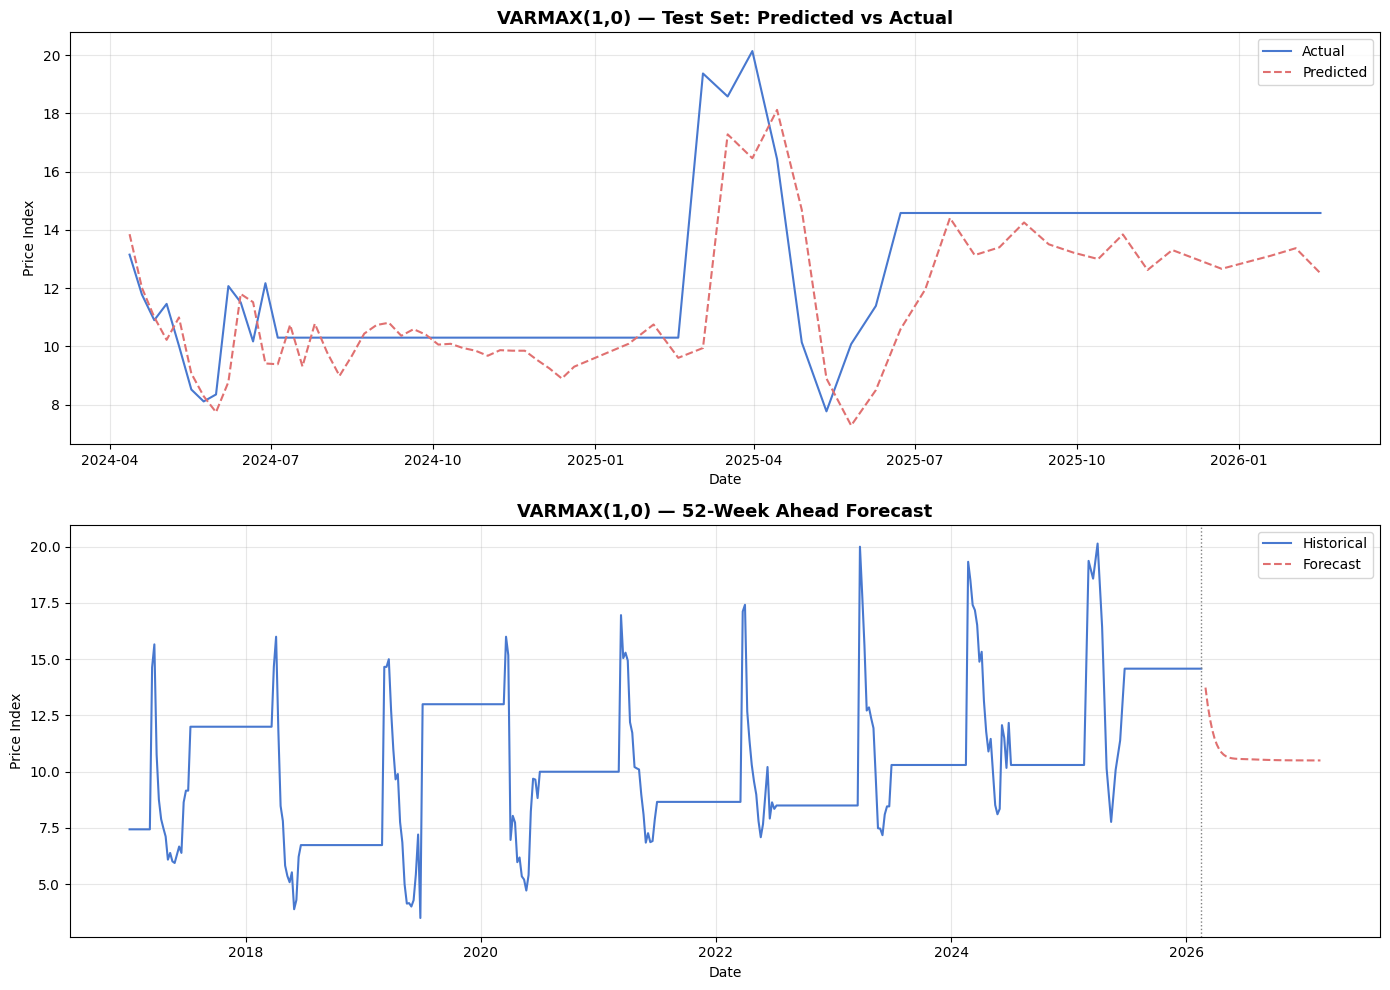

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

ax = axes[0]
ax.plot(actual_test.index,   actual_test.values,   color="#4878CF", lw=1.5, label="Actual")
ax.plot(pred_test_lvl.index, pred_test_lvl.values, color="#E07070", lw=1.5, ls="--", label="Predicted")
ax.set_title(f"VARMAX({best_p},{best_q}) — Test Set: Predicted vs Actual", fontsize=13, fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Price Index")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(df[TARGET_COL].index, df[TARGET_COL].values, color="#4878CF", lw=1.5, label="Historical")
ax.plot(fc_series.index,      fc_series.values,       color="#E07070", lw=1.5, ls="--", label="Forecast")
ax.axvline(df.index[-1], color="gray", ls=":", lw=1)
ax.set_title(f"VARMAX({best_p},{best_q}) — 52-Week Ahead Forecast", fontsize=13, fontweight="bold")
ax.set_xlabel("Date"); ax.set_ylabel("Price Index")
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "varmax_predictions_forecast.png", dpi=300, bbox_inches="tight")
plt.show()

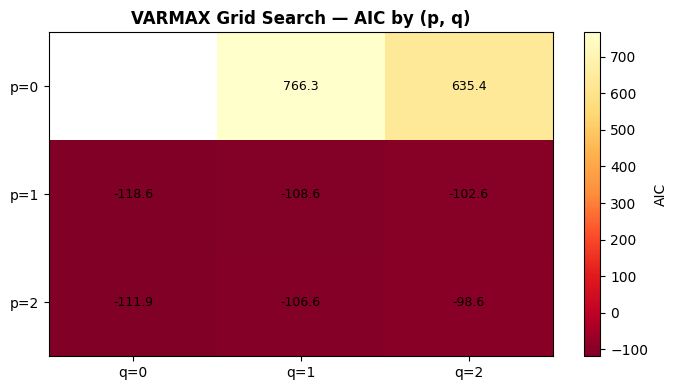

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
pivot   = grid_df.pivot(index="p", columns="q", values="aic")
im      = ax.imshow(pivot.values, cmap="YlOrRd_r", aspect="auto")
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels([f"q={c}" for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels([f"p={r}" for r in pivot.index])
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax, label="AIC")
ax.set_title("VARMAX Grid Search — AIC by (p, q)", fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "varmax_grid_search_aic.png", dpi=300, bbox_inches="tight")
plt.show()

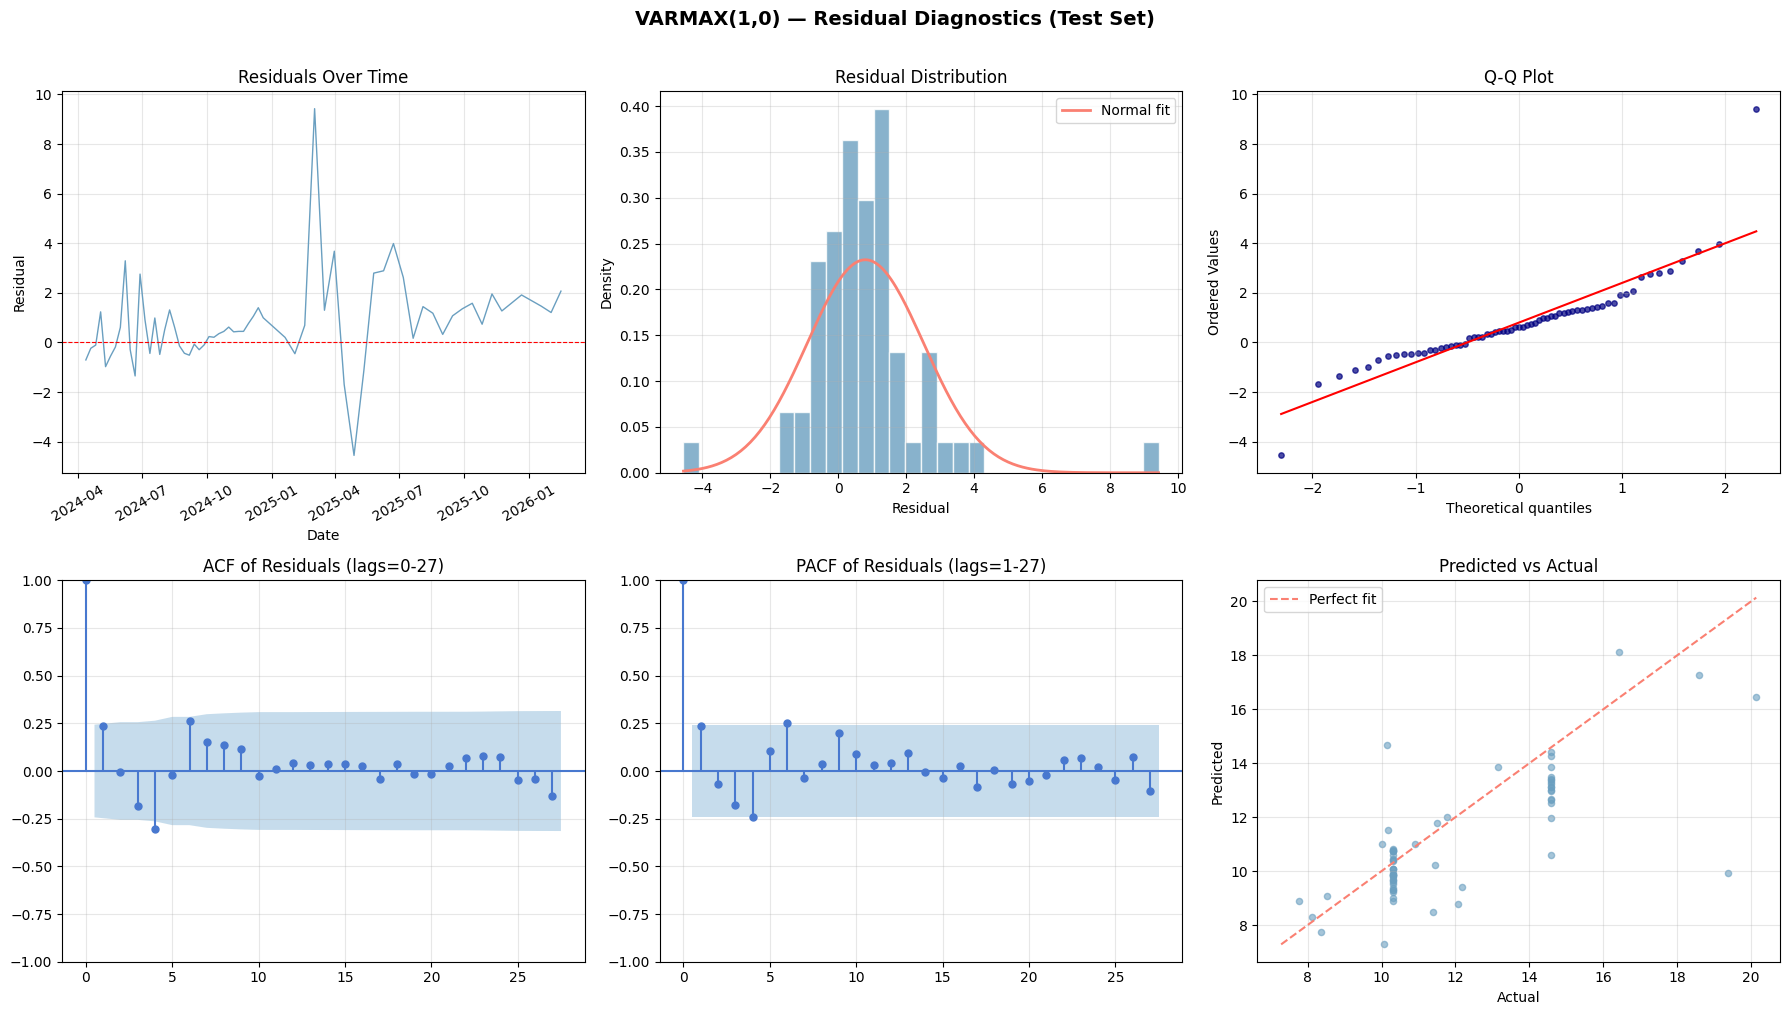

In [17]:
# ── Plot 3: Residual Diagnostics ──────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
fig.suptitle(f"VARMAX({best_p},{best_q}) — Residual Diagnostics (Test Set)",
             fontsize=14, fontweight="bold", y=1.01)
gs  = gridspec.GridSpec(2, 3, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(actual_test.index, residuals, color="#6A9FC0", lw=1)
ax1.axhline(0, color="red", ls="--", lw=0.8)
ax1.set_title("Residuals Over Time"); ax1.set_xlabel("Date"); ax1.set_ylabel("Residual")
ax1.tick_params(axis="x", rotation=30); ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(residuals, bins=30, color="#6A9FC0", edgecolor="white", alpha=0.8, density=True)
xr  = np.linspace(residuals.min(), residuals.max(), 200)
ax2.plot(xr, stats.norm.pdf(xr, residuals.mean(), residuals.std()), color="salmon", lw=2, label="Normal fit")
ax2.set_title("Residual Distribution"); ax2.set_xlabel("Residual"); ax2.set_ylabel("Density")
ax2.legend(); ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
(osm, osr), (slope, intercept, _) = stats.probplot(residuals, dist="norm")
ax3.scatter(osm, osr, color="navy", s=15, alpha=0.7)
ax3.plot(osm, slope * np.array(osm) + intercept, color="red", lw=1.5)
ax3.set_title("Q-Q Plot"); ax3.set_xlabel("Theoretical quantiles"); ax3.set_ylabel("Ordered Values")
ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(gs[1, 0])
plot_acf(residuals, lags=27, ax=ax4, title="ACF of Residuals (lags=0-27)",
         color="#4878CF", vlines_kwargs={"colors": "#4878CF"})
ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(gs[1, 1])
plot_pacf(residuals, lags=27, ax=ax5, title="PACF of Residuals (lags=1-27)",
          color="#4878CF", vlines_kwargs={"colors": "#4878CF"}, method="ywm")
ax5.grid(True, alpha=0.3)

ax6 = fig.add_subplot(gs[1, 2])
ax6.scatter(actual_test.values, pred_test_lvl.values, color="#6A9FC0", s=20, alpha=0.6)
lims = [min(actual_test.min(), pred_test_lvl.min()), max(actual_test.max(), pred_test_lvl.max())]
ax6.plot(lims, lims, color="salmon", ls="--", lw=1.5, label="Perfect fit")
ax6.set_title("Predicted vs Actual"); ax6.set_xlabel("Actual"); ax6.set_ylabel("Predicted")
ax6.legend(); ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "varmax_residual_diagnostics.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
pd.DataFrame({
    "date":      actual_test.index,
    "actual":    actual_test.values,
    "predicted": pred_test_lvl.values,
    "residual":  residuals,
}).to_csv(RESULTS_DIR / "varmax_test_predictions.csv", index=False)

pd.DataFrame({
    "date":           fc_series.index,
    "forecast_price": fc_series.values,
}).to_csv(RESULTS_DIR / "varmax_52week_forecast.csv", index=False)

grid_df.to_csv(RESULTS_DIR / "varmax_grid_search_results.csv", index=False)

print(f"\n✓ Saved: varmax_test_predictions.csv")
print(f"✓ Saved: varmax_52week_forecast.csv")
print(f"✓ Saved: varmax_grid_search_results.csv")


✓ Saved: varmax_test_predictions.csv
✓ Saved: varmax_52week_forecast.csv
✓ Saved: varmax_grid_search_results.csv


## VARMAX(1,0) Model — Results Write-Up

### Model Overview

The VARMAX grid search evaluated all (p,q) combinations up to (2,2) using AIC across a two-column endogenous system with five exogenous regressors (fuel price, CPI, API, fertiliser, SPPI). The grid search heatmap reveals a clear structural finding: any model with at least one autoregressive lag (p ≥ 1) dramatically outperforms pure MA specifications, with AIC values clustering around -100 to -120 versus +635 to +766 for the MA-only rows. VARMAX(1,0) was selected as the best model with an AIC of -118.6, marginally edging out VARMAX(2,0) at -111.9 and VARMAX(1,1) at -108.6. The additional MA component in (1,1) and the extra AR lag in (2,0) both provide diminishing returns relative to the parameter cost, validating the parsimony of (1,0). The final model was fit across all 20 endogenous produce series with 730 parameters, making it substantially leaner than the VAR(12) that imploded in the previous iteration.

---

### Training Dynamics

Unlike the VAR, the VARMAX does not exhibit the catastrophic train-test collapse seen previously. The model achieves a train RMSE of 1.32 and test RMSE of 1.89 — a meaningful but not extreme gap, suggesting the model has generalised reasonably rather than memorised training patterns. The model summary confirms stable estimation for most series, with autoregressive lag-1 coefficients close to but below 1.0 for persistent series like Leeks (0.90), Asparagus (0.83), Cabbage (0.90), and both tomato varieties (~0.72–0.74), while more volatile series show weaker AR persistence. The warning about a near-singular covariance matrix (condition number 4.36×10²⁰) is worth noting — this reflects collinearity across the 20 produce series and suggests the error covariance estimates should be treated with caution, though it does not invalidate the point forecasts.

---

### Predictive Performance

| Split | RMSE | MAE | MAPE |
|-------|------|-----|------|
| Train | 1.3159 | 0.7243 | 8.12% |
| Val | 1.9222 | 0.9606 | 7.83% |
| Test | 1.8939 | 1.2507 | 9.79% |

The test MAPE of 9.79% is a significant improvement over both the VAR (76.58%) and broadly comparable to the S-Mamba benchmark (11.44%), representing the strongest statistical baseline result so far. Notably, the validation MAPE of 7.83% is actually lower than the train MAPE of 8.12% — an unusual but not alarming pattern that can arise when the validation window happens to cover a less volatile period than training. The sMAPE of 10.42% on the test set is similarly competitive.

The MASE values tell a more cautious story. At 2.46 on the test set, the model still underperforms a naïve random walk baseline, meaning week-over-week price changes are not being tracked with sufficient precision to beat simple persistence forecasting. This is partly attributable to the spring 2025 price spike visible in the predicted vs. actual plot, where the model lags the sharp upward move by several weeks before recovering.

Looking at the test set plot, the VARMAX tracks the general level and directional movements reasonably well across the range of 8–15, including the mid-range plateau of 2024 and the recovery to ~14.5 in late 2025. The key failure point is the March–April 2025 spike to ~20, where the model peaks around 18 and undershoots by roughly 2 units — consistent with the positive residual mean of 0.80, indicating systematic under-prediction during high-price regimes.

---

### Exogenous Variable Contributions

The coefficient tables reveal that the macro regressors have heterogeneous effects across produce categories. The API (agricultural price index) shows the most consistent significance, appearing with meaningful positive coefficients in the Asparagus equation (0.111, p < 0.001) and the Strawberries equation (0.055, p < 0.001), suggesting these premium items are more exposed to upstream input cost pressures. SPPI (services producer price index) also achieves significance across several equations including Asparagus, Capsicums, Pak choi, and Tomatoes (Round), consistent with the hypothesis that distribution and retail service costs transmit into fresh produce pricing. Fuel price and fertiliser are largely insignificant across most equations at the individual series level, though this may reflect multicollinearity with the CPI and API rather than a genuine absence of effect.

---

### Residual Diagnostics

The diagnostic picture is mixed but meaningfully better than the VAR. The **Ljung-Box test** (p = 0.290) passes cleanly, confirming no significant autocorrelation structure remains in the test residuals — the VARMAX has successfully captured the temporal dependence in the series. This is a clear improvement over the VAR, which failed this test.

The **Jarque-Bera test** again rejects normality (JB = 245.5, p ≈ 0.000), driven by strong right skew (1.63) and very high excess kurtosis (11.95). The residual distribution plot makes this visually clear — the bulk of errors cluster tightly between -1 and +3, but a long right tail extends to +9.4, driven almost entirely by the spring 2025 spike weeks. The Q-Q plot shows near-normal behaviour across the central quantiles but severe upper-tail departure, confirming this is an extreme-event rather than systemic normality problem. As with S-Mamba, Gaussian prediction intervals will understate true forecast uncertainty.

The ACF and PACF plots show residual autocorrelations comfortably within confidence bands from lag 2 onwards, with only a mild exceedance at lag 4 in the PACF. The predicted vs. actual scatter shows reasonable linear alignment along the diagonal across the 8–14 range, with dispersion increasing above 14 as the model struggles with the spike regime.

---

### 52-Week Forecast

The 52-week forecast projects a mean price index of **10.76**, ranging between **10.50 and 13.74**. The forecast descends from recent elevated levels (~14.5) toward a plateau around 10.5–11.0 within the first few months, then stabilises for the remainder of the horizon. This mean-reversion toward historical mid-range values is physically plausible for seasonal produce but the flat plateau from mid-2026 onward reflects the LOCF treatment of exogenous variables — without any projected changes in fuel, CPI, or API, the model has no external driver to generate further variation. The forecast is best interpreted as a steady-state baseline conditional on current macro conditions persisting, rather than a dynamic projection.

---

### Summary & Comparison to S-Mamba

VARMAX(1,0) is the strongest classical baseline so far, recovering cleanly from the VAR's catastrophic failure and producing a test MAPE of 9.79% that is marginally better than S-Mamba's 11.44%. However, this comparison warrants some caution: the VARMAX benefits from observing 20 endogenous price series simultaneously, effectively pooling information across all produce categories, while S-Mamba was evaluated on a single aggregated index. The VARMAX also passes the Ljung-Box test that S-Mamba fails, suggesting its residual autocorrelation structure is better resolved — though both models share the heavy-tailed residual problem around volatility spikes.

The primary remaining weaknesses are the MASE > 1 indicating a naïve baseline is still competitive for week-to-week tracking, the near-singular covariance matrix suggesting redundancy across the 20 series, and the flat long-run forecast driven by static exogenous assumptions. Dimensionality reduction of the endogenous system — for instance aggregating correlated produce categories or using principal components — would likely both stabilise the covariance estimation and improve out-of-sample performance.